In [6]:

import importlib, subprocess, sys

_required = [
    "numpy", "torch", "torchvision", "Pillow",
    "scikit-learn", "scipy", "matplotlib",
    "xgboost", "ipywidgets", "pandas",
]

for pkg in _required:
    import_name = {"Pillow": "PIL", "scikit-learn": "sklearn"}.get(pkg, pkg)
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
    else:
        print(f"{pkg} already installed.")

numpy already installed.
torch already installed.
torchvision already installed.
Pillow already installed.
scikit-learn already installed.
scipy already installed.
matplotlib already installed.
xgboost already installed.
ipywidgets already installed.
pandas already installed.


In [7]:
import os, random, glob
import numpy as np
import pandas as pd
import torch
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

random_seed = 42

In [8]:

IN_COLAB = None

if IN_COLAB is None:
    try:
        import google.colab
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT      = "/content/drive/MyDrive/content/banana_dataset"
    #TEST_ROOT = "/content/drive/MyDrive/content/banana_dataset/test"

    DOWNLOAD_ROOT = "/content/drive/MyDrive/content/banana_dataset_downloads"
else:
    _base     = os.getcwd()

    ROOT      = os.path.join(_base, "banana_dataset")
    #TEST_ROOT = os.path.join(_base, "banana_dataset", "test")

    DOWNLOAD_ROOT = os.path.join(_base, "banana_dataset_downloads")


print(f"Running {'in Colab' if IN_COLAB else 'locally'}")
print(f"ROOT      = {ROOT}")


CLASSES = ["healthy", "unhealthy"]

IMG_SIZE = (224, 224)


Running locally
ROOT      = c:\lrn\GATech\Courses\ISYE 6740 Computational Data Analysis\Project\CommonCode\tree-species-ml\banana_dataset


## Classify images to identify the health of banana plants 

The `banana_dataset` directory contains two classes, `healthy` and `unhealthy`, with images already standardized to 224 x 224.  
This section:

1. Builds a labelled dataset from those two folders.
2. Extracts a compact feature vector for each image using a pretrained ResNet-18 backbone.
3. Splits the dataset into stratified training and testing sets.
4. Trains the following classifiers with 5-fold stratified cross-validation:
    - Logistic Regression  (LogisticRegression)
    - Linear Support Vector Machine (SVC with `kernel="linear"`)
    - Non-linear SVM with RBF kernel (SVC with `kernel="rbf"`)
    - Random Forest (RandomForestClassifier)
    - Gradient Boosting (HistGradientBoostingClassifier)

5. Reports cross-validation metrics and final test-set performance and compares the results across the models.



Looking for images in c:\lrn\GATech\Courses\ISYE 6740 Computational Data Analysis\Project\CommonCode\tree-species-ml\banana_dataset\healthy...
Looking for images in c:\lrn\GATech\Courses\ISYE 6740 Computational Data Analysis\Project\CommonCode\tree-species-ml\banana_dataset\unhealthy...


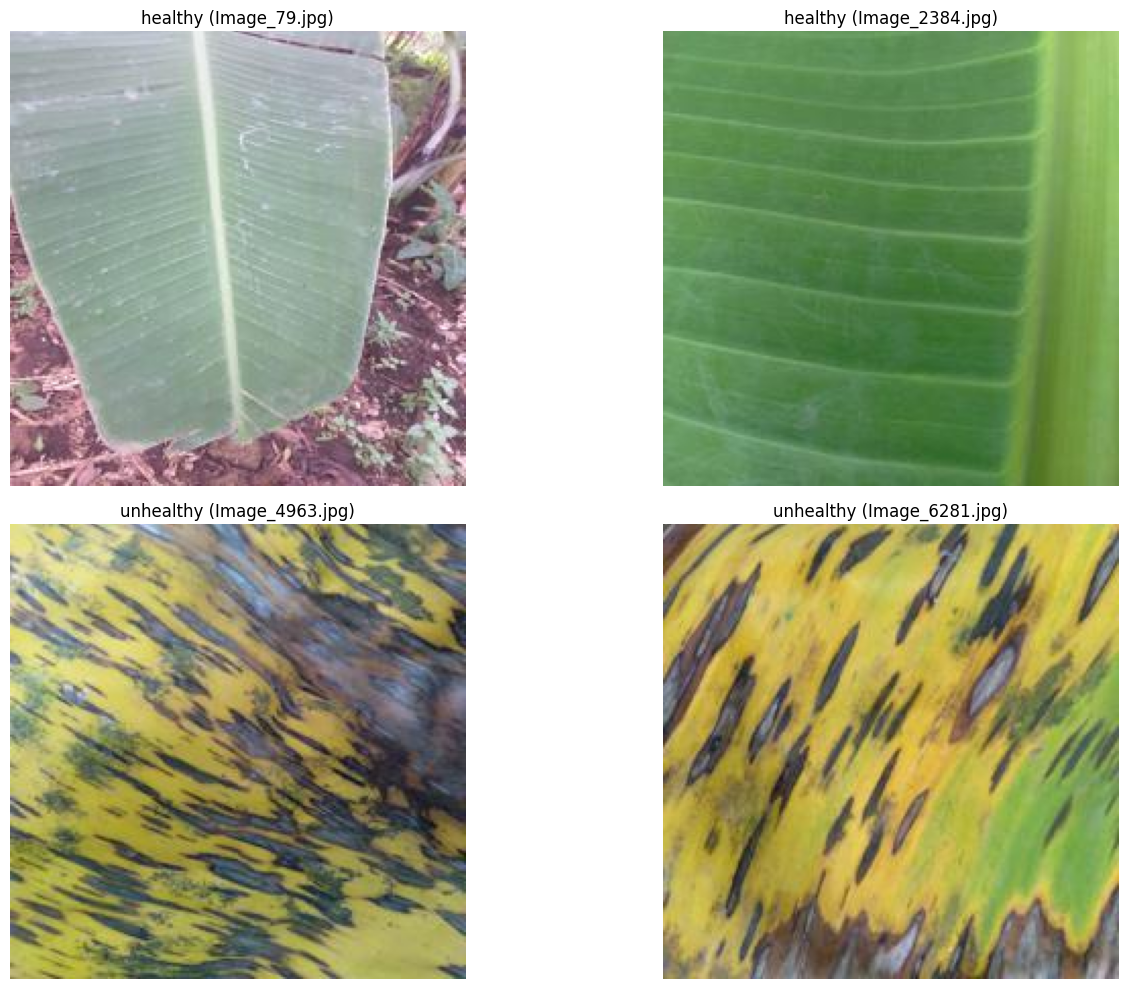

In [9]:
#Show a few random images from the dataset
EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")

def show_random_images(root, classes, num_images=5):
    plt.figure(figsize=(15, 5 * len(classes)))
    for i, cls in enumerate(classes):
        class_dir = os.path.join(root, cls)
        print(f"Looking for images in {class_dir}...")
        files = []
        for ext in EXTENSIONS:
            files.extend(glob.glob(os.path.join(class_dir, ext)))
        
        files = sorted([path for path in files if not os.path.basename(path).startswith(".")])
        if len(files) == 0:
            print(f"No images found for class '{cls}' in {class_dir}.")
            continue
        
        selected_files = random.sample(files, min(num_images, len(files)))
        
        for j, file in enumerate(selected_files):
            img = Image.open(file).convert("RGB")
            plt.subplot(len(classes), num_images, i * num_images + j + 1)
            plt.imshow(img)
            plt.title(f"{cls} ({os.path.basename(file)})")
            plt.axis("off")
    plt.tight_layout()
    plt.show()

show_random_images(ROOT, CLASSES, num_images=2)


In [10]:

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Building a labelled dataset  from banana_dataset/healthy and banana_dataset/unhealthy.
MODELING_MAX_PER_CLASS = 1000
rng = random.Random(42)


def collect_dataset(root, classes, max_per_class=None):
    samples = []
    targets = []

    for label, cls in enumerate(classes):
        class_dir = os.path.join(root, cls)
        files = []
    
        for ext in EXTENSIONS:
            files.extend(glob.glob(os.path.join(class_dir, ext)))
    
        files = sorted([path for path in files if not os.path.basename(path).startswith(".")])
        
        print (f"{cls}: {len(files)} files found, Max per class: {max_per_class}, ", end="")
        
        # If there are more files than the maximum limit randomly choose the files
        if max_per_class is not None and len(files) > max_per_class:
            files = sorted(rng.sample(files, k=max_per_class))
        
        samples.extend(files)
        targets.extend([label] * len(files))
        
        print(f"{cls}: {len(files)} files used")
    
    return samples, np.array(targets)

###
all_paths, all_labels = collect_dataset(ROOT, CLASSES, max_per_class=MODELING_MAX_PER_CLASS)
if len(all_paths) == 0:
    raise ValueError(f"No images found under {ROOT}. Run the preprocessing cell first.")

print(f"\nTotal sampled images: {len(all_paths)}")
print({cls: int((all_labels == idx).sum()) for idx, cls in enumerate(CLASSES)})

healthy: 5628 files found, Max per class: 1000, healthy: 1000 files used
unhealthy: 5767 files found, Max per class: 1000, unhealthy: 1000 files used

Total sampled images: 2000
{'healthy': 1000, 'unhealthy': 1000}


In [11]:
#Feature extraction and dimensionality reduction 

# Use a pretrained ResNet-18 backbone to convert each image into a numeric feature vector.
device = "cuda" if torch.cuda.is_available() else "cpu"
feature_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

resnet = models.resnet18(weights="IMAGENET1K_V1")
resnet.fc = torch.nn.Identity()
resnet = resnet.to(device).eval()


def extract_resnet_features(paths, batch_size=32):
    features = []
    for start in range(0, len(paths), batch_size):
        batch_paths = paths[start:start + batch_size]
        batch_tensors = []
        
        for path in batch_paths:
            with Image.open(path) as img:
                batch_tensors.append(feature_transform(img.convert("RGB")))
        
        batch = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            batch_features = resnet(batch).cpu().numpy()
        features.append(batch_features)
        
        print(f"Extracted {start + len(batch_paths)}/{len(paths)}", end="\r")
    
    print()
    return np.vstack(features)


X_raw = extract_resnet_features(all_paths)
y = all_labels
print(f"Raw feature matrix: {X_raw.shape}")

# Reduce dimensions using PCA to speed up cross-validation.
pca = PCA(n_components=min(64, X_raw.shape[0] - 1, X_raw.shape[1]), random_state=random_seed)
X = pca.fit_transform(X_raw)
print(f"PCA feature matrix: {X.shape}")

Extracted 2000/2000
Raw feature matrix: (2000, 512)
PCA feature matrix: (2000, 64)


In [12]:
# Split into train/test; use training partition only for cross-validation.
import time

X_train, X_test, y_train, y_test, train_paths, test_paths = train_test_split(
    X,
    y,
    all_paths,
    test_size=0.2,
    stratify=y,
    random_state=random_seed,
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

models_list = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, random_state=random_seed),
    ),
    "Linear SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", random_state=random_seed),
    ),
    "Non-linear SVM (RBF)": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", random_state=random_seed),
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=random_seed,
        n_jobs=-1,
    ),
    "Gradient Boosted Tree": HistGradientBoostingClassifier(
        max_iter=300,
        random_state=random_seed,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
}

cv_rows = []
trained_models = {}
test_rows = []
confusion_matrices = {}

for name, model in models_list.items():
    # --- Cross-validation timing ---
    t0 = time.perf_counter()
    cv_scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_elapsed = time.perf_counter() - t0

    cv_rows.append({
        "Model": name,
        "CV Accuracy": cv_scores["test_accuracy"].mean(),
        "CV Precision": cv_scores["test_precision"].mean(),
        "CV Recall": cv_scores["test_recall"].mean(),
        "CV F1": cv_scores["test_f1"].mean(),
        "CV Time (s)": cv_elapsed,
    })

    # --- Final fit + predict timing ---
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_elapsed = time.perf_counter() - t0

    trained_models[name] = model

    t0 = time.perf_counter()
    y_pred = model.predict(X_test)
    predict_elapsed = time.perf_counter() - t0

    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    test_rows.append({
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Fit Time (s)": fit_elapsed,
        "Predict Time (s)": predict_elapsed,
    })

cv_results = sorted(cv_rows, key=lambda row: row["CV F1"], reverse=True)
test_results = sorted(test_rows, key=lambda row: row["Test Accuracy"], reverse=True)

print("Cross-validation summary (training split only):")
for row in cv_results:
    print(
        f"{row['Model']:24s} "
        f"Acc={row['CV Accuracy']:.3f} "
        f"Prec={row['CV Precision']:.3f} "
        f"Rec={row['CV Recall']:.3f} "
        f"F1={row['CV F1']:.3f} "
        f"CV Time={row['CV Time (s)']:.1f}s"
    )

print("\nTest-set accuracy:")
for row in test_results:
    print(
        f"{row['Model']:24s} "
        f"Acc={row['Test Accuracy']:.3f} "
        f"Fit={row['Fit Time (s)']:.2f}s "
        f"Predict={row['Predict Time (s)']:.3f}s"
    )

best_model_name = cv_results[0]["Model"]
best_model = trained_models[best_model_name]
best_predictions = best_model.predict(X_test)

print(f"\nBest model by CV F1: {best_model_name}")
print("\nClassification report on the held-out test set:")
print(classification_report(y_test, best_predictions, target_names=CLASSES))


Training samples: 1600
Testing samples : 400
Cross-validation summary (training split only):
Non-linear SVM (RBF)     Acc=0.996 Prec=0.996 Rec=0.996 F1=0.996 CV Time=0.3s
Logistic Regression      Acc=0.994 Prec=0.994 Rec=0.994 F1=0.994 CV Time=0.1s
Gradient Boosted Tree    Acc=0.992 Prec=0.992 Rec=0.992 F1=0.992 CV Time=9.3s
Linear SVM               Acc=0.991 Prec=0.991 Rec=0.991 F1=0.991 CV Time=0.1s
Random Forest            Acc=0.980 Prec=0.980 Rec=0.980 F1=0.980 CV Time=4.4s

Test-set accuracy:
Logistic Regression      Acc=0.998 Fit=0.01s Predict=0.001s
Gradient Boosted Tree    Acc=0.998 Fit=1.26s Predict=0.012s
Non-linear SVM (RBF)     Acc=0.995 Fit=0.05s Predict=0.027s
Linear SVM               Acc=0.985 Fit=0.04s Predict=0.001s
Random Forest            Acc=0.983 Fit=0.84s Predict=0.100s

Best model by CV F1: Non-linear SVM (RBF)

Classification report on the held-out test set:
              precision    recall  f1-score   support

     healthy       1.00      0.99      0.99       

In [15]:
# Model comparison table — CV metrics + held-out test accuracy + timing side by side

cv_df   = pd.DataFrame(cv_rows)
test_df = pd.DataFrame(test_rows)

comparison_df = (
    cv_df
    .merge(test_df, on="Model")
    .sort_values("CV F1", ascending=False)
    .reset_index(drop=True)
)


perf_cols   = ["CV Accuracy", "CV Precision", "CV Recall", "CV F1", "Test Accuracy"]
timing_cols = ["CV Time (s)", "Fit Time (s)", "Predict Time (s)"]
all_cols    = perf_cols + timing_cols

# Helper: highlight best (green) and worst (red) per column with white text for contrast
def highlight_best(s):
    best = s.max()
    return [
        "background-color: #137333; color: white; font-weight: bold" if v == best else ""
        for v in s
    ]

def highlight_worst_perf(s):
    worst = s.min()
    return [
        "background-color: #a50000; color: white; font-weight: bold" if v == worst else ""
        for v in s
    ]

# For timing: lower is better — highlight min as green, max as red
def highlight_fastest(s):
    best = s.min()
    return [
        "background-color: #137333; color: white; font-weight: bold" if v == best else ""
        for v in s
    ]

def highlight_slowest(s):
    worst = s.max()
    return [
        "background-color: #a50000; color: white; font-weight: bold" if v == worst else ""
        for v in s
    ]

styled = (
    comparison_df.style
    .apply(highlight_best,       subset=perf_cols,   axis=0)
    .apply(highlight_worst_perf, subset=perf_cols,   axis=0)
    .apply(highlight_fastest,    subset=timing_cols, axis=0)
    .apply(highlight_slowest,    subset=timing_cols, axis=0)
    .format({col: "{:.4f}" for col in perf_cols},   na_rep="—")
    .format({col: "{:.2f}"  for col in timing_cols}, na_rep="—")
    .set_caption("Model comparison: 5-fold CV (train split), held-out test performance, and timing")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
        {"selector": "th",      "props": [("background-color", "#333333"), ("color", "white"), ("font-weight", "bold")]},
    ])
)

display(styled)


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV Time (s),Test Accuracy,Fit Time (s),Predict Time (s)
0,Non-linear SVM (RBF),0.996250,0.996266,0.996250,0.996250,0.35,0.995000,0.05,0.03
1,Logistic Regression,0.993750,0.993826,0.993750,0.993750,0.08,0.997500,0.01,0.00
2,Gradient Boosted Tree,0.991875,0.991917,0.991875,0.991875,9.35,0.997500,1.26,0.01
3,Linear SVM,0.990625,0.990758,0.990625,0.990624,0.14,0.985000,0.04,0.00
4,Random Forest,0.980000,0.980143,0.980000,0.979999,4.40,0.982500,0.84,0.10


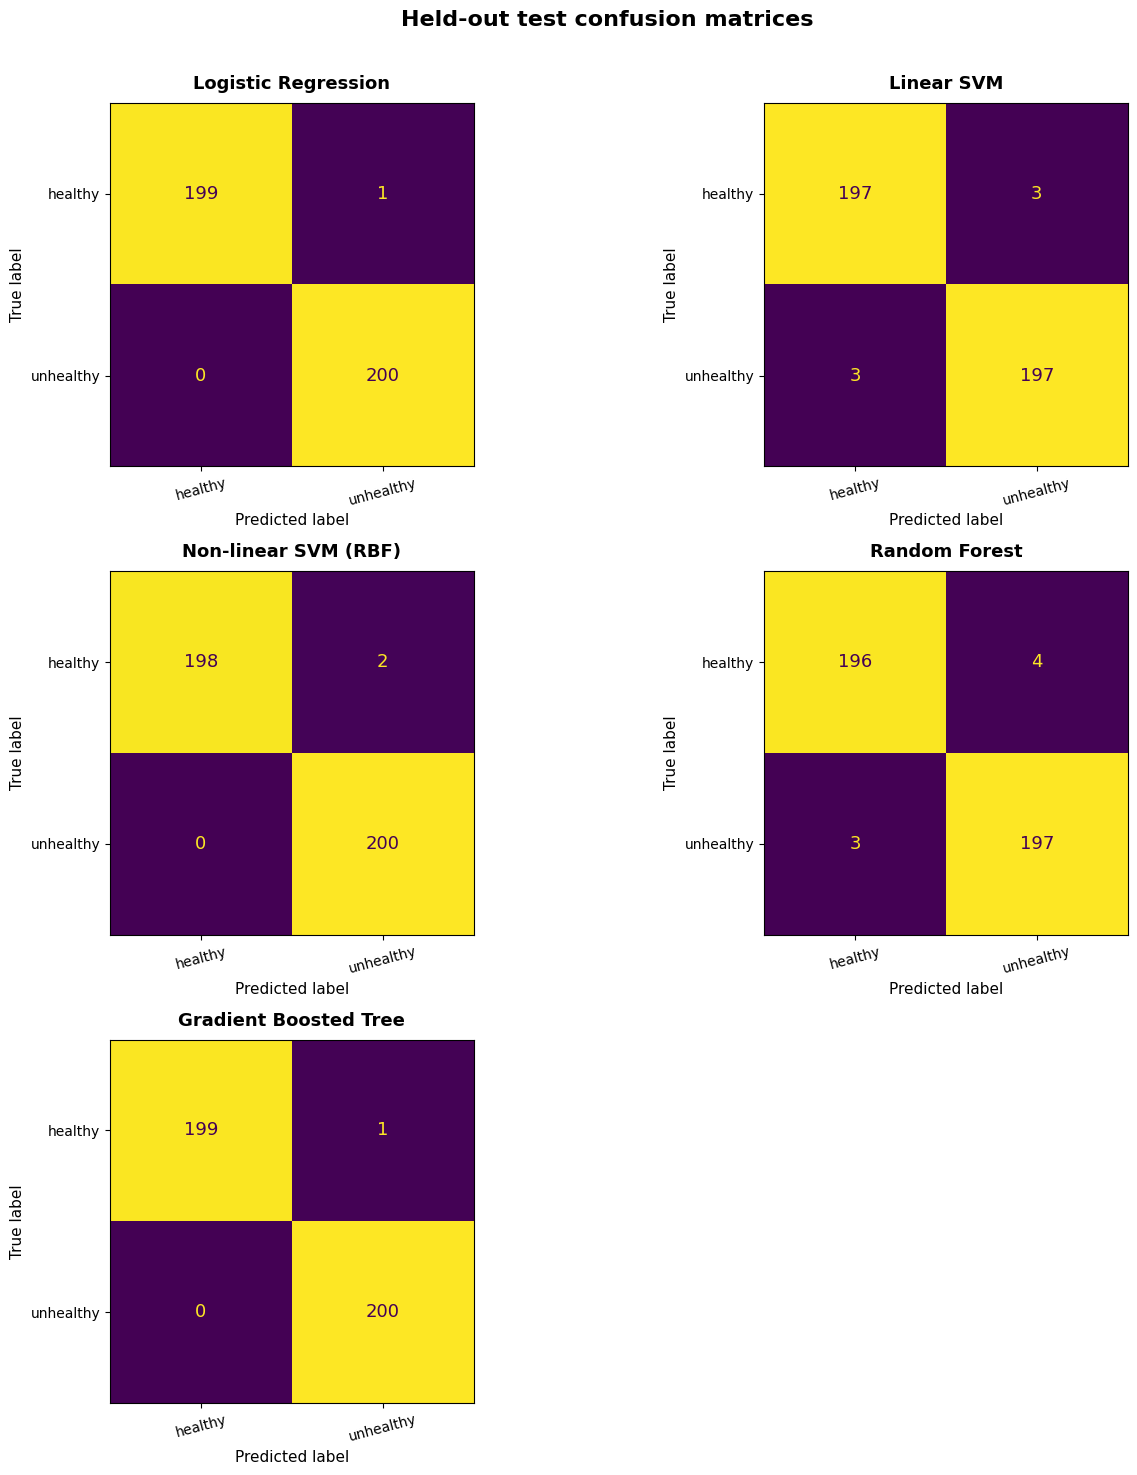

In [14]:
# Plotting confusion matrices for all models on the held-out test set — 2 per row.
import math

n_models = len(models_list)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.atleast_2d(axes).flatten()

for ax, name in zip(axes, models_list):
    matrix = confusion_matrices[name]
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=15)
    ax.set_title(name, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel(ax.get_xlabel(), fontsize=11)
    ax.set_ylabel(ax.get_ylabel(), fontsize=11)
    ax.tick_params(labelsize=10)
    for text in disp.text_.ravel():
        text.set_fontsize(13)

# Hide unused subplot slots (e.g. 5 models → 1 empty slot in a 3×2 grid)
for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle("Held-out test confusion matrices", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
